In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import session
import h5py
import pickle
from scipy import stats

In [2]:
# set the main data directory (this needs to be changed by each user)
maindir = '/Volumes/ExternalSSD/Credit_assignement'

In [3]:
# get all the sessions to analyze
mouse = 'M1'
layers = 'L1' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

mouse = 'M1'
layers = 'L23' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

mouse = 'M2'
layers = 'L1' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

mouse = 'M2'
layers = 'L5' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

mouse = 'M3'
layers = 'L1' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

mouse = 'M3'
layers = 'L23' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

mouse = 'M4'
layers = 'L1' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

mouse = 'M4'
layers = 'L5' #'L1' 'L23' or 'L5'
sessionfile = open(mouse+'_'+layers+'_Sessions.txt','r')
allsessions = allsessions + [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()


In [4]:
print(allsessions)

['720520553', '722126561', '723323411', '723322122', '721975393', '721032982', '720519615', '716711420', '715244457', '717030161', '716425232', '724422062', '725010342', '726844248', '727683236', '727680211', '725009252', '724421207', '726837871', '718742560', '722188453', '719034388', '718579351']


In [90]:
def get_dff_excess_bricks(minsess,maxsess,bsize,bdir,mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict):
    sts = [] #surprise chunks
    nts = [] #no surprise chunks
    nbas = [] #no surp baseline
    sbas = [] #surp baseline
    
    for snum in range(minsess,maxsess):
        S = allsessions[snum]
        print(S)
        ssegs= sdict[S].bricks.get_segs_by_criteria(surp=mysurp,stimPar2=bdir,stimPar1=bsize,remconsec=True)             
        sframes = brickdict[S].get_2pframes_by_seg(ssegs[0])
        straces = sdict[S].get_roi_segments(sframes,padding=pad)
        sts.append(straces[:,pad[0]:pad[0]+numframes,0:numtotake])#surprise responses
        sbas.append(straces[:,0:pad[0],0:numtotake])
        
        nsegs= sdict[S].bricks.get_segs_by_criteria(surp=0,stimPar2=bdir,stimPar1=bsize,remconsec=False) 
        nframes = brickdict[S].get_2pframes_by_seg(nsegs[0])
        ntraces = sdict[S].get_roi_segments(nframes,padding=pad)
        nts.append(ntraces[:,pad[0]:pad[0]+numframes,0:250])#no surprise responses
        nbas.append(ntraces[:,0:pad[0],0:250])
    
    
    flat_sts  = np.array([item for sublist in sts for item in sublist])
    flat_nts = np.array([item for sublist in nts for item in sublist])

    flat_nbas = np.array([item for sublist in nbas for item in sublist])
    flat_sbas = np.array([item for sublist in sbas for item in sublist])
        
    dff_sts = np.divide(np.nanmean(flat_sts,axis=1) - np.nanmean(flat_sbas,axis=1),np.nanmean(flat_sbas,axis=1))
    dff_nts = np.divide(np.nanmean(flat_nts,axis=1) - np.nanmean(flat_nbas,axis=1),np.nanmean(flat_nbas,axis=1))
        
    excess_activity = np.nanmean(dff_sts,axis=1)-np.nanmean(dff_nts,axis=1)
    excess_activity[abs(excess_activity)>1E6] = 'nan'
    return excess_activity

In [26]:
# create a dictionary with Session objects prepared for analysis
sdict = {}
brickdict = {}
for sess in allsessions:                       # remove the :1 to get all sessions ready
    print("\nCreating session {}...".format(sess))
    sdict[sess] = session.Session(maindir,sess)    # creates a session object to work with
    sdict[sess].extract_info()  
    brickdict[sess] = session.Stim(sdict[sess],0,'bricks')
    print("finished session {}.".format(sess))


Creating session 720520553...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_720520553
Loading running data...
Loading ROI trace info...





finished session 720520553.

Creating session 722126561...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_722126561
Loading running data...
Loading ROI trace info...





finished session 722126561.

Creating session 723323411...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_723323411
Loading running data...
Loading ROI trace info...





finished session 723323411.

Creating session 723322122...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle alrea

Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_725010342
Loading running data...
Loading ROI trace info...





finished session 725010342.

Creating session 726844248...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_726844248
Loading running data...
Loading ROI trace info...





finished session 726844248.

Creating session 727683236...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_727683236
Loading running data...
Loading ROI trace info...





finished session 727683236.

Creating session 727680211...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_ses

In [118]:
numframes = 30 #number of frames to take df/f over
numtotake = 6 #number of surprise trials to take
pad=(30,10)
mysurp = 1

print(mysurp)
print('M1 L1')
M1L1_diffs_surp_R256 = get_dff_excess_bricks(0,3,256,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M1L1_diffs_surp_L128 = get_dff_excess_bricks(0,3,128,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)

print('M1 L23')
M1L23_diffs_surp_R256 = get_dff_excess_bricks(3,7,256,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M1L23_diffs_surp_L128 = get_dff_excess_bricks(3,7,128,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)

print('M3 L1')
M3L1_diffs_surp_R256 = get_dff_excess_bricks(11,15,256,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M3L1_diffs_surp_R128 = get_dff_excess_bricks(11,15,128,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)

print('M3 L23')
M3L23_diffs_surp_R256 = get_dff_excess_bricks(15,19,256,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M3L23_diffs_surp_R128 = get_dff_excess_bricks(15,19,128,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)


1
M1 L1
720520553
722126561
723323411
720520553
722126561
723323411
M1 L23
723322122
721975393
721032982
720519615
723322122
721975393
721032982
720519615
M3 L1
724422062
725010342
726844248
727683236
724422062
725010342
726844248
727683236
M3 L23
727680211
725009252
724421207
726837871
727680211
725009252
724421207
726837871


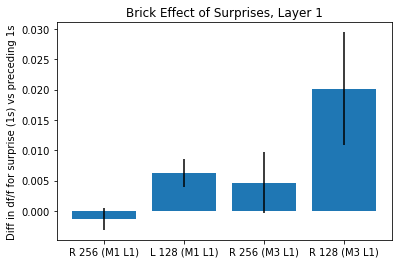

In [125]:
means = [np.mean(M1L1_diffs_surp_R256),np.mean(M1L1_diffs_surp_L128),np.mean(M3L1_diffs_surp_R256),np.mean(M3L1_diffs_surp_R128)]
stds = [np.std(M1L1_diffs_surp_R256)/np.sqrt(len(M1L1_diffs_surp_R256)),np.std(M1L1_diffs_surp_L128)/np.sqrt(len(M1L1_diffs_surp_L128)),np.std(M3L1_diffs_surp_R256)/np.sqrt(len(M3L1_diffs_surp_R256)),np.std(M3L1_diffs_surp_R128)/np.sqrt(len(M3L1_diffs_surp_R128))]
plt.bar([1,2,3,4],means,yerr=stds)
plt.xticks([1,2,3,4],['R 256 (M1 L1)','L 128 (M1 L1)','R 256 (M3 L1)','R 128 (M3 L1)'])
plt.ylabel('Diff in df/f for surprise (1s) vs preceding 1s')
plt.title('Brick Effect of Surprises, Layer 1')
plt.savefig('Layer1_Mouse1and3_Surp_BrickResponses_BarPlot_Delta.png')

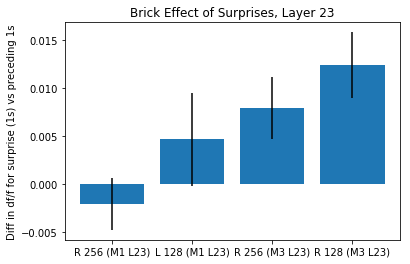

In [126]:
means = [np.mean(M1L23_diffs_surp_R256),np.mean(M1L23_diffs_surp_L128),np.mean(M3L23_diffs_surp_R256),np.mean(M3L23_diffs_surp_R128)]
stds = [np.std(M1L23_diffs_surp_R256)/np.sqrt(len(M1L23_diffs_surp_R256)),np.std(M1L23_diffs_surp_L128)/np.sqrt(len(M1L23_diffs_surp_L128)),np.std(M3L23_diffs_surp_R256)/np.sqrt(len(M3L23_diffs_surp_R256)),np.std(M3L23_diffs_surp_R128)/np.sqrt(len(M3L23_diffs_surp_R128))]
plt.bar([1,2,3,4],means,yerr=stds)
plt.xticks([1,2,3,4],['R 256 (M1 L23)','L 128 (M1 L23)','R 256 (M3 L23)','R 128 (M3 L23)'])
plt.ylabel('Diff in df/f for surprise (1s) vs preceding 1s')
plt.title('Brick Effect of Surprises, Layer 23')
plt.savefig('Layer23_Mouse1and3_Surp_BrickResponses_BarPlot_Delta.png')

In [117]:
numframes = 30 #number of frames to take df/f over
numtotake = 6 #number of surprise trials to take
pad=(30,10)
mysurp = 1

print(mysurp)
print('M2 L1')
M2L1_diffs_surp_R256 = get_dff_excess_bricks(7,9,256,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M2L1_diffs_surp_L128 = get_dff_excess_bricks(7,9,128,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M2L1_diffs_surp_L256 = get_dff_excess_bricks(7,9,256,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M2L1_diffs_surp_R128 = get_dff_excess_bricks(7,9,128,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)

print('M2 L5')
M2L5_diffs_surp_R256 = get_dff_excess_bricks(9,11,256,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M2L5_diffs_surp_L128 = get_dff_excess_bricks(9,11,128,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M2L5_diffs_surp_L256 = get_dff_excess_bricks(9,11,256,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M2L5_diffs_surp_R128 = get_dff_excess_bricks(9,11,128,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)

print('M4 L1')
M4L1_diffs_surp_R256 = get_dff_excess_bricks(19,21,256,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M4L1_diffs_surp_L128 = get_dff_excess_bricks(19,21,128,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M4L1_diffs_surp_L256 = get_dff_excess_bricks(19,21,256,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M4L1_diffs_surp_R128 = get_dff_excess_bricks(19,21,128,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)

print('M4 L5')
M4L5_diffs_surp_R256 = get_dff_excess_bricks(21,23,256,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M4L5_diffs_surp_L128 = get_dff_excess_bricks(21,23,128,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M4L5_diffs_surp_L256 = get_dff_excess_bricks(21,23,256,'left',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)
M4L5_diffs_surp_R128 = get_dff_excess_bricks(21,23,128,'right',mysurp,numframes,numtotake,pad,allsessions,sdict,brickdict)


1
M2 L1
716711420
715244457
716711420
715244457
716711420
715244457
716711420
715244457
M2 L5
717030161
716425232
717030161
716425232
717030161
716425232
717030161
716425232
M4 L1
718742560
722188453
718742560
722188453
718742560
722188453
718742560
722188453
M4 L5
719034388
718579351
719034388
718579351
719034388
718579351
719034388
718579351


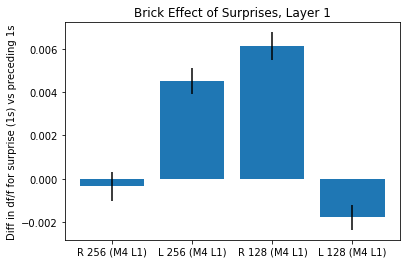

In [127]:
means = [np.mean(M4L1_diffs_surp_R256),np.mean(M4L1_diffs_surp_L256),np.mean(M4L1_diffs_surp_R128),np.mean(M4L1_diffs_surp_L128)]
stds = [np.std(M4L1_diffs_surp_R256)/np.sqrt(len(M4L1_diffs_surp_R256)),np.std(M4L1_diffs_surp_L256)/np.sqrt(len(M4L1_diffs_surp_L256)),np.std(M4L1_diffs_surp_R128)/np.sqrt(len(M4L1_diffs_surp_R128)),np.std(M4L1_diffs_surp_L128)/np.sqrt(len(M4L1_diffs_surp_L128))]
plt.bar([1,2,3,4],means,yerr=stds)
plt.xticks([1,2,3,4],['R 256 (M4 L1)','L 256 (M4 L1)','R 128 (M4 L1)','L 128 (M4 L1)'])
plt.ylabel('Diff in df/f for surprise (1s) vs preceding 1s')
plt.title('Brick Effect of Surprises, Layer 1')
plt.savefig('Layer1_Mouse4_Surp_BrickResponses_BarPlot_Delta.png')

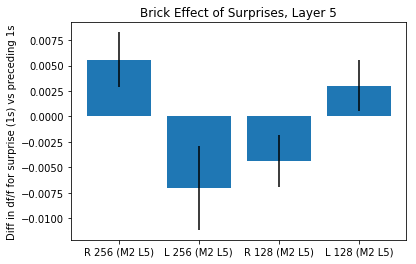

In [128]:
means = [np.nanmean(M2L5_diffs_surp_R256),np.nanmean(M2L5_diffs_surp_L256),np.nanmean(M2L5_diffs_surp_R128),np.nanmean(M2L5_diffs_surp_L128)]
stds = [np.nanstd(M2L5_diffs_surp_R256)/np.sqrt(len(M2L5_diffs_surp_R256)),np.nanstd(M2L5_diffs_surp_L256)/np.sqrt(len(M2L5_diffs_surp_L256)),np.nanstd(M2L5_diffs_surp_R128)/np.sqrt(len(M2L5_diffs_surp_R128)),np.nanstd(M2L5_diffs_surp_L128)/np.sqrt(len(M2L5_diffs_surp_L128))]
plt.bar([1,2,3,4],means,yerr=stds)
plt.xticks([1,2,3,4],['R 256 (M2 L5)','L 256 (M2 L5)','R 128 (M2 L5)','L 128 (M2 L5)'])
plt.ylabel('Diff in df/f for surprise (1s) vs preceding 1s')
plt.title('Brick Effect of Surprises, Layer 5')
plt.savefig('Layer5_Mouse2_Surp_BrickResponses_BarPlot_Delta.png')

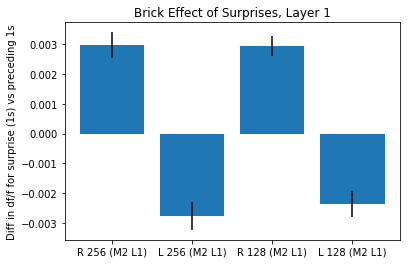

In [129]:
means = [np.mean(M2L1_diffs_surp_R256),np.mean(M2L1_diffs_surp_L256),np.mean(M2L1_diffs_surp_R128),np.mean(M2L1_diffs_surp_L128)]
stds = [np.std(M2L1_diffs_surp_R256)/np.sqrt(len(M2L1_diffs_surp_R256)),np.std(M2L1_diffs_surp_L256)/np.sqrt(len(M2L1_diffs_surp_L256)),np.std(M2L1_diffs_surp_R128)/np.sqrt(len(M2L1_diffs_surp_R128)),np.std(M2L1_diffs_surp_L128)/np.sqrt(len(M2L1_diffs_surp_L128))]
plt.bar([1,2,3,4],means,yerr=stds)
plt.xticks([1,2,3,4],['R 256 (M2 L1)','L 256 (M2 L1)','R 128 (M2 L1)','L 128 (M2 L1)'])
plt.ylabel('Diff in df/f for surprise (1s) vs preceding 1s')
plt.title('Brick Effect of Surprises, Layer 1')
plt.savefig('Layer1_Mouse2_Surp_BrickResponses_BarPlot_Delta.png')

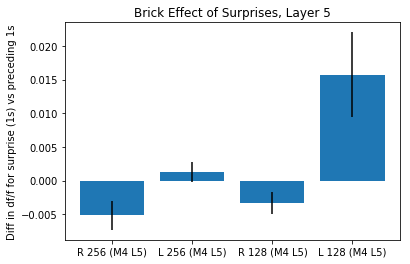

In [130]:
means = [np.nanmean(M4L5_diffs_surp_R256),np.nanmean(M4L5_diffs_surp_L256),np.nanmean(M4L5_diffs_surp_R128),np.nanmean(M4L5_diffs_surp_L128)]
stds = [np.nanstd(M4L5_diffs_surp_R256)/np.sqrt(len(M4L5_diffs_surp_R256)),np.nanstd(M4L5_diffs_surp_L256)/np.sqrt(len(M4L5_diffs_surp_L256)),np.nanstd(M4L5_diffs_surp_R128)/np.sqrt(len(M4L5_diffs_surp_R128)),np.nanstd(M4L5_diffs_surp_L128)/np.sqrt(len(M4L5_diffs_surp_L128))]
plt.bar([1,2,3,4],means,yerr=stds)
plt.xticks([1,2,3,4],['R 256 (M4 L5)','L 256 (M4 L5)','R 128 (M4 L5)','L 128 (M4 L5)'])
plt.ylabel('Diff in df/f for surprise (1s) vs preceding 1s')
plt.title('Brick Effect of Surprises, Layer 5')
plt.savefig('Layer5_Mouse4_Surp_BrickResponses_BarPlot_Delta.png')